<div style="color:blue">
    
# **General Instructions for the ML Coding Problems**

Please follow these instructions carefully to ensure a smooth evaluation process.

## **1. Notebook Submission**
- You **must** make a copy of this notebook and append your **full name** to the filename before submitting (e.g., `[OriginalNotebookName]_[YourName].ipynb`).
- Share  your notebook copy with inaio@acmindia.org [This is for your own safety so that you do not accidentally lose any changes while editing the notebook]
- After solving the questions, ensure you mention the correct URL of your  modified notebook in the test form
- Also answer questions on external resources used and link to LLM chats used for each problem in the main test form

## **2. Attempting the Questions**
- Carefully **read each problem statement** before attempting.
- **Attempt all parts** of each question.
- Each question is organized into the following parts
   - **DATA**, **TASK**, **HELPER CODE [Optional]** and **ANSWER**
- **Follow the function signatures** provided. Do not modify them.
- You only need to edit the cells in the **ANSWER** sections
- If required, you may also add other modules under **IMPORTS** and **INSTALLATION INSTRUCTIONS**
- Do not edit the other cells, especially those marked with **DO NOT MODIFY** which are meant for evaluation
- You may add new cells to the notebook with extra code as desired
  

## **3. Scoring Criteria**
Your score will be based on the following factors with distribution varying across each problem.
- **Soundness & Creativity** of your approach.  
  - Include a clear description and rationale of your solution methodology in the notebook (in markdown cells)
  - Solutions that showcase your understanding of data and ML will garner more points
- **Code Implementation & Readability**
  - Ensure your implementation is correct and works
  - Incomplete non-working code will be awarded  partial marks based on problem-wise rubric
  - In case you have a solution but are unsure about some aspect, you can define a function that solves that aspect and present the rest of the solution
  - Use comments to explain important parts of your code.
- **Performance of Your Model**:
  - Each task will be assessed based on specified performance metrics both on shared datasets and secret datasets
  - Different performance ranges will receive different scores.
  - Secret datasets used for last section will be shared along with the final results

**Points associated with cells are marked at the beginning of the cell**
    
## **4. Dataset Usage**
- **Only use the datasets provided** in this test.
- Do **not** use the provided test data set for training.
- Do **not** use external datasets for training or testing.
- If the submitted performance metrics cannot be reproduced with your code and original datasets, then you will lose all the points associated with model performance.


</div>

<div style="color:blue">
    
## Problem 5: Classifying the Unnown: Decoding the Mystery of Genetics and Terrain [14 pts]

On the island of Poké, strange creatures called "Unnown" roam diverse terrains—volcanic landscapes, forests, swamps, and more. Professor Log, a leading researcher, has been studying their physiological attributes and geographic locations to uncover patterns in their distinctive genetic strains, labeled as **A, B, C, and D**.

While some relationships exist between terrain-attribute and genetic strains, the mapping is not clear cut which makes classification challenging since labels are few.

Professor Log's goal is to develop a predictive model that classifies an Unnown’s genetic strain based on its location (x, y) and physiological traits, without having to do expensive genetic testing. To bootstrap this effort, he has conducted genetic testing for a small number of creatures.

Your challenge is to use your data expertise to assist Professor Log in classying the Unnown according to genetic strain.

This problem consists of 5 tasks (students must attempt first 4; the 5th is for private evaluation):

-  **Q1: Exploring the Unnown** [4 pts]  
-  **Q2: Clustering the Unnown based on Location** [4 pts]  
-  **Q3: Training a Genetic Strain Classifier** [4 pts]
-  **Q4: Testing your Unnown Classifier on New Public Dataset** [1 pts]  
-  **Q5: Testing your Unnown Classifier on New Private Dataset** [1 pts] [NOT FOR STUDENTS TO ATTEMPT]  


</div>

<div style="color:blue">
    
### INSTALLATION  

</div>

In [ ]:
! pip install uv
! uv pip install pandas numpy scikit-learn  matplotlib seaborn

Using Python 3.11.11 environment at: /usr
Audited 5 packages in 115ms


<div style="color:blue">
    
### IMPORTS
</div>

In [ ]:
# EDIT: [O pts]
# You may add any other free python packages along with comments

# Scikit learn imports
from sklearn.pipeline import Pipeline
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier


# Data Types
from typing import Any, List, Optional, Set, Tuple

# Data handling
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computations and array handling

# Machine Learning - Process
from sklearn.model_selection import train_test_split  # Splitting dataset

# Machine Learning - Models
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

# Machine Learning - Feature Transformations
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Feature transformations if needed
from sklearn.compose import ColumnTransformer #Transforming columns

# Model evaluation
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score, completeness_score, confusion_matrix, accuracy_score

# Classifier models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Visualization
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns  # Enhanced data visualization


**COPY DATA**

In [ ]:
# Copy data
!mkdir /content/data
!wget https://raw.githubusercontent.com/inaiogit/stage2test/main/test/unnown_test_public.csv
!wget https://raw.githubusercontent.com/inaiogit/stage2test/main/test/unnown_train.csv
!mv unnown_test_public.csv unnown_train.csv data/

--2025-03-02 05:12:12--  https://raw.githubusercontent.com/inaiogit/stage2test/main/test/unnown_test_public.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3671 (3.6K) [text/plain]
Saving to: ‘unnown_test_public.csv’

unnown_test_public. 100%[===================>]   3.58K  --.-KB/s    in 0s      

2025-03-02 05:12:13 (40.1 MB/s) - ‘unnown_test_public.csv’ saved [3671/3671]

--2025-03-02 05:12:13--  https://raw.githubusercontent.com/inaiogit/stage2test/main/test/unnown_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4

<div style="color:blue">
    
# **Q1: Exploring the Unnown** [4 pts]

Before building any predictive model, it is  crucial to explore the data to uncover patterns, relationships.
In particular, you need to examine Prof. Log's hunch that location signal is highly predictive of the genetic label.

</div>


<div style="color:blue">

### **DATA**

Prof Log shares with you a train **dataset** containing detailed observations of Unnown specimens, their geographic locations, physiological attributes with genetic labels for a subset of specimens. Each row corresponds to an individual specimen.

- **`unnown_train_path`**: Training dataset with recorded Unnown observations.

#### Columns
- **`Specimen_ID`** - Unique identifier for each Unnown specimen.  
- **`X, Y`** – Geographic coordinates of capture, i.e., terrain  
- **`Specimen_Size`** – Measured size of the Unnown (continuous variable).  
- **`Diet_Type`** – Categorical variable indicating whether the Unnown is **herbivorous, carnivorous, or omnivorous**.  
- **`Genetic_Label`** – The target variable, representing one of four possible Unnown genetic strains (**A, B, C, D**) which is missing for most specimens.  

</div>


In [ ]:
# Training datasets
unnown_train_path = "data/unnown_train.csv"  # Unnown specimen data


<div style="color:blue">
    
### **TASK**

Analyze the data and record your observations below:
   - (a) Is there a correlation between the location variables and the genetic label and can you directly use them as features for classification? Justify
   - (b) Prof. Log suggests using K-means to identify clusters that could map to genetic groups? Is that a good idea? Justify.

</div>


<div style="color:blue">
    
### **HELPER CODE**

</div>

In [ ]:
def learn_clusters(
    df: pd.DataFrame,
    cols: list,
    method: str = "kmeans",
    k: int = 3,
    eps: float = 0.5,
    min_samples: int = 5,
) -> pd.DataFrame:
    """
    Applies a clustering algorithm on location data and appends a Cluster_ID column.

    Parameters:
    - df (pd.DataFrame): Input DataFrame containing location and specimen ID.
    - cols (list): location columns to use for clustering.
    - method (str): Clustering algorithm to use. Options: 'kmeans', 'dbscan', 'agglomerative', 'gmm', 'spectral'.
    - k (int): Number of clusters (for k-means, spectral, agglomerative, and GMM).
    - eps (float): Maximum distance between two samples for DBSCAN clustering.
    - min_samples (int): Minimum samples per cluster for DBSCAN.

    Returns:
    - pd.DataFrame: The original DataFrame with an additional 'Cluster_ID' column.
    """
    df = df.copy(deep=True)
    # Extract and standardize data
    scaled_data = StandardScaler().fit_transform(df[cols])

    # Choose clustering method
    if method == "kmeans":
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        df["Cluster_ID"] = model.fit_predict(scaled_data)
    elif method == "dbscan":
        model = DBSCAN(eps=eps, min_samples=min_samples)
        df["Cluster_ID"] = model.fit_predict(scaled_data)
    elif method == "agglomerative":
        model = AgglomerativeClustering(n_clusters=k)
        df["Cluster_ID"] = model.fit_predict(scaled_data)
    elif method == "gmm":
        model = GaussianMixture(n_components=k, random_state=42)
        df["Cluster_ID"] = model.fit_predict(scaled_data)
    elif method == "spectral":
        model = SpectralClustering(n_clusters=k, affinity="nearest_neighbors", random_state=42)
        df["Cluster_ID"] = model.fit_predict(scaled_data)
    else:
        raise ValueError(f"Unsupported clustering method: {method}")
    return df


<div style="color:red">
    
# ANSWER

</div>

In [ ]:
# EDIT: [2 pts]
# Add your data exploration code here
data = pd.read_csv(unnown_train_path)
data.head()

,X,Y,Specimen_Size,Diet_Type,Genetic_Label,Specimen_ID
0,5.253094,5.844291,12.364020,Herbivore,NaN,1
1,11.373440,0.378987,15.651165,Herbivore,NaN,2
2,-2.879896,2.051275,15.697827,Carnivore,NaN,3
3,2.100327,1.883168,16.417212,Carnivore,NaN,4
4,6.112791,-2.614663,9.439839,Carnivore,C,5


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              700 non-null    float64
 1   Y              700 non-null    float64
 2   Specimen_Size  700 non-null    float64
 3   Diet_Type      700 non-null    object 
 4   Genetic_Label  50 non-null     object 
 5   Specimen_ID    700 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 32.9+ KB


In [ ]:
data.Genetic_Label.unique()

array([nan, 'C', 'B', 'D', 'A'], dtype=object)

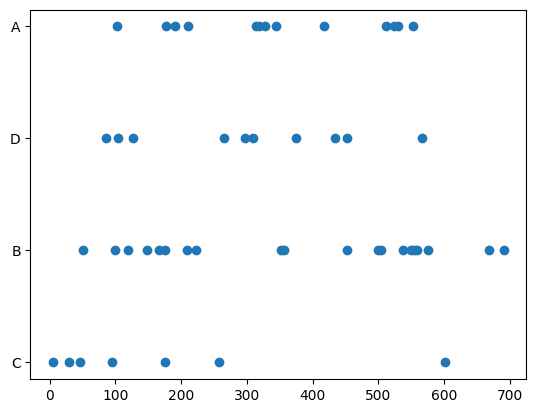

In [ ]:
plt.scatter(data.dropna().Specimen_ID,data.dropna().Genetic_Label)
plt.show()

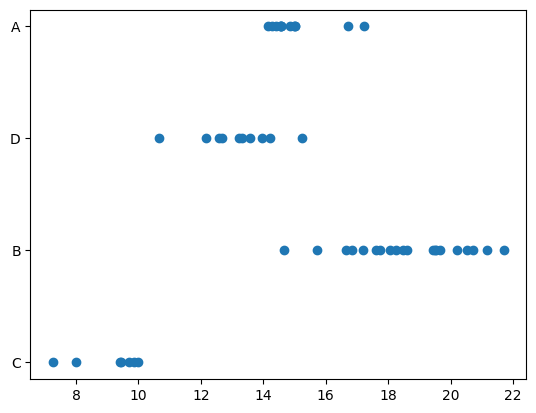

In [ ]:
plt.scatter(data.dropna().Specimen_Size,data.dropna().Genetic_Label)
plt.show()

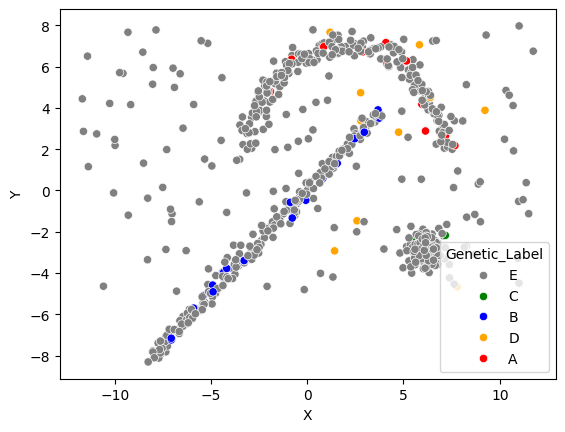

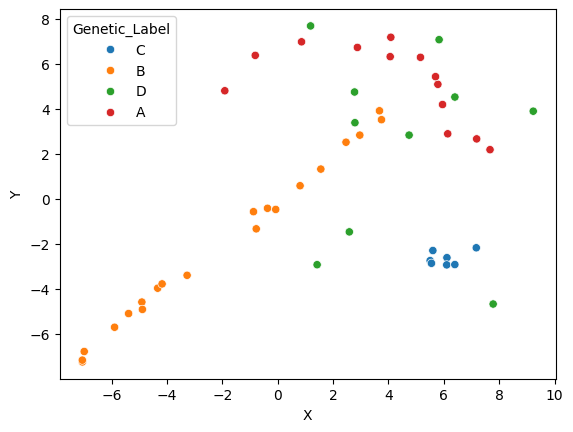

In [ ]:
# Plot Unnown location with different colors for known genetic labels and gray for the unlabeled ones
sns.scatterplot(data.fillna('E'),x='X',y='Y',hue='Genetic_Label',palette={
    'A': 'red',
    'B': 'blue',
    'C': 'green',
    'D': 'orange',
    'E': 'grey'
})
plt.show()
sns.scatterplot(data,x='X',y='Y',hue='Genetic_Label')
plt.show()

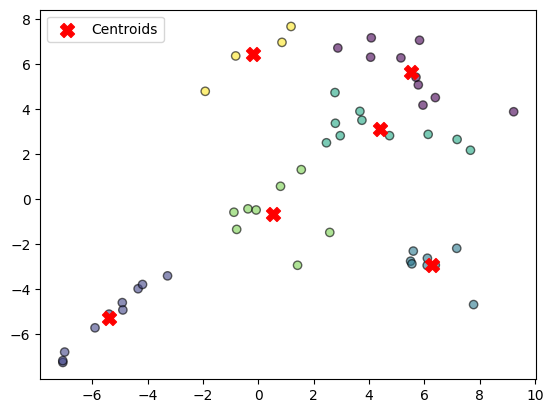

In [ ]:
# Plot Unnown location with different colors for k-means clusters (choose K based on what you feel is appropriate)
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(data.dropna()[['X','Y']])
centers = kmeans.cluster_centers_
plt.scatter(data.dropna().X,data.dropna().Y, c=kmeans.labels_, cmap='viridis', alpha=0.6, edgecolor='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', label='Centroids')
plt.legend()
plt.show()

## **EDIT THIS: [2 pts]**

### (a)  Is there a correlation between the location variables and the genetic label? Can you directly use them as features for classification?  Justify. [1 pt]
- 1st Part: Yes, 2nd Part: No
- Reasons: There is a clear corelation between the location and genetic label as we can see from the plot. However, between label A and D, location isn't enough. We also might want to scale the input data as it is very noisy.

### (b) Prof. Log suggests using K-means to identify clusters that could map to genetic groups. Is that a good idea? Justify. [1 pt]
- No
- Reasons: While using K-Means is enough for B and C, it fails to differentiate between A and D.



<div style="color:blue">
<hr>
    
# **Q2: Clustering the Unnown based on Location** [4 pts]
</div>

<div style="color:blue">

### **DATA**

Use the same train **dataset** as in Q1

- **`unnown_train_path`**: Training dataset with recorded Unnown observations.


</div>


In [ ]:
# Training datasets
unnown_train_path = "data/unnown_train.csv"  # Unnown specimen data


<div style="color:blue">
    
### **TASK**

#### (a) Create a function **learn_location_clusters** as per the signature defined below.  
If you scroll down, you will see cells with the skeletal code that you need to flesh out.

---

#### **Function 1: `learn_location_clusters`**

```python
def learn_location_clusters(df: pd.DataFrame, k: int) -> pd.DataFrame:
    """
    Applies k-Means clustering on the given location columns and appends a Cluster_ID to the DataFrame.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing location and specimen ID.
    - k (int): The number of clusters to form.

    Returns:
    - pd.DataFrame: The original DataFrame with an additional 'Cluster_ID' column.
    """
```

#### (b) Evaluate the goodness of resulting clustering relative to the known labels using the helper code

</div>

<div style="color:blue">
    
### **HELPER CODE**
</div>

In [ ]:
# HELPER CODE
# You may choose to use or modify any of the below code in your solution, but it is NOT mandatory

def plot_confusion_matrix(true_labels, predicted_labels, title="Confusion Matrix"):
    """
    Generates and displays a confusion matrix.

    Parameters:
    - true_labels (array-like): Ground truth labels (e.g., genetic labels).
    - predicted_labels (array-like): Predicted labels (e.g., Cluster_IDs).
    - title (str): Title for the confusion matrix plot.

    Returns:
    - None (displays the plot).
    """
    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=sorted(set(predicted_labels)), yticklabels=sorted(set(true_labels)))
    plt.xlabel("Predicted Clusters")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()


def evaluate_location_cluster_predictive_utility(file_path: str, k: int = 4) -> dict:
    """
    Reads a CSV file, applies k-Means clustering on (X, Y) location data, evaluates clustering performance
    using NMI, Homogeneity, and Completeness, and visualizes a confusion matrix of clusters vs. genetic labels.

    Parameters:
    - file_path (str): Path to the CSV file containing the dataset.
    - k (int): Number of clusters for k-Means clustering (default: 4).

    Returns:
    - dict: Dictionary of clustering evaluation metrics (NMI, Homogeneity, Completeness).
    """

    # Load dataset
    df = pd.read_csv(file_path)

    # Ensure required columns exist
    required_cols = ["X", "Y", "Genetic_Label"]
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"Missing required columns. Ensure {required_cols} exist in the dataset.")

    # Drop rows where X or Y are missing
    df = df.dropna(subset=["X", "Y"])

    # Apply clustering on (X, Y) using learn_location_clusters
    df = learn_location_clusters(df, location_cols=["X", "Y"], specimen_id_col="Specimen_ID", k=k)

    # Filter dataset to compute metrics only where Genetic_Label is available
    df_labeled = df.dropna(subset=["Genetic_Label"])

    # Convert genetic labels to integer if needed
    labels_true = df_labeled["Genetic_Label"].map({
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
    })
    labels_pred = df_labeled["Cluster_ID"]

    # Compute clustering evaluation metrics
    metrics = {
        "NMI": normalized_mutual_info_score(labels_true, labels_pred),
        "Homogeneity": homogeneity_score(labels_true, labels_pred),
        "Completeness": completeness_score(labels_true, labels_pred)
    }

    # Print results
    print("\nClustering Evaluation Metrics (Only on Available Genetic Labels):")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    # Generate and display the confusion matrix
    plot_confusion_matrix(labels_true, labels_pred, title="Confusion Matrix: Genetic Label vs. Cluster ID")

    return metrics



<div style="color:red">
    
# ANSWER

</div>

## **EDIT: [1 pts]**
#### You can jot down initial notes here and flesh this out in more detail after the implementation.

### **Describe Your Solution Approach**

#### **• Data Exploration Notes** [0.5 pt]
  -   Just location is not enough to find out the genetic label.
  -   As stated above, A and D have similar location patterns.
  -   Everything except specimen ID seems to be useful.

#### **• Modeling Strategy & Choices** [0.5 pt]
  -   I am applying K-Means on the input data
  -   I could scale it, but it is not asked by the question


In [ ]:
# EDIT: [2 pts]
# Implement the learning of location clusters
# You can edit the partial implementation but keep the signature same

def learn_location_clusters(df: pd.DataFrame, location_cols: list, specimen_id_col: str, k: int) -> pd.DataFrame:
    """
    Applies k-Means clustering on the given location columns and appends a Cluster_ID to the DataFrame.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing location and specimen ID.
    - location_cols (list): location columns to use for clustering.
    - k (int): The number of clusters to form.

    Returns:
    - pd.DataFrame: The original DataFrame with an additional 'Cluster_ID' column.
    """
    df["Cluster_ID"] = KMeans(n_clusters=k).fit_predict(df[['X','Y']])
    return df


Clustering Evaluation Metrics (Only on Available Genetic Labels):
NMI: 0.5268
Homogeneity: 0.5438
Completeness: 0.5109


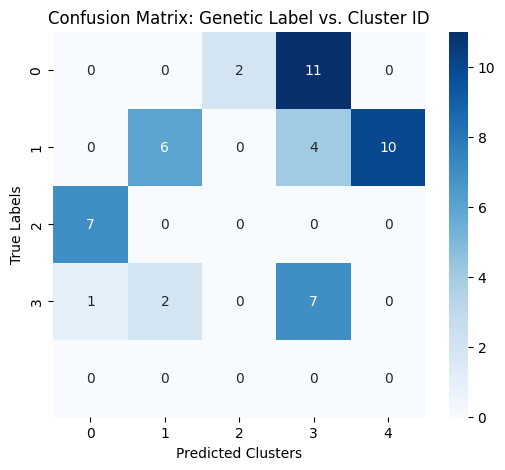

{'NMI': 0.5268427855206459, 'Homogeneity': 0.5437642626071661, 'Completeness': 0.5109426876721497}


In [ ]:
# DO NOT MODIFY except for choice of k - you can set it to your preferred value
# Run this code and observe the clustering metrics
# [pts depend on performance range]
chosen_k = 5
print(evaluate_location_cluster_predictive_utility(unnown_train_path, chosen_k))

## **EDIT: [1 pts]**
#### You can jot down clustering metrics below

### **Train Set Performance**
  - K: 5
  - Normalized Mutual information: 0.53
  - Homogeneity Score: 0.54
  - Completeness Score: 0.51
  - Confusion Matrix Output: (ran above)
      

### **Any Additional Observations**
  -   The model seems to perform best with k = 5

<div style="color:blue">
<hr>    

# **Q3: Training a Genetic Strain Classifier** [4 pts]

</div>

<div style="color:blue">

### **DATA**

Use the same train **dataset** as in Q1

- **`unnown_train_path`**: Training dataset with recorded Unnown observations.


</div>


In [ ]:
# Training datasets
unnown_train_path = "data/unnown_train.csv"  # Unnown specimen data


<div style="color:blue">
    
### **TASK**

Create two functions **learn_unnown_classifier** and **classify_unnown** as per the signatures defined below.  
If you scroll down, you will see cells with the skeletal code that you need to flesh out.

---

#### **Function 1: `learn_unnown_classifier`**
```python
def learn_unnown_classifier(train_file_path: str) -> Any:
    """
    Loads the Unnown dataset from a CSV file, trains a classifier using both location and other available features,
    (but no cluster labels) and returns the trained model.

    Parameters:
    - train_file_path (str): Path to CSV file containing labeled Unnown data.

    Returns:
    - model: Trained machine learning model (can take any form).
    """
```
---

#### **Function 2: `classify_unnown`**
```python
def classify_unnown(features: pd.DataFrame, model: Any) -> pd.Series:
    """
    Uses the trained model to classify an Unnown specimen into one of four genetic strain classes (A, B, C, D).

    Parameters:
    - features (pd.DataFrame): A dataframe containing feature values (e.g., pd.DataFrame({"X": 45.3, "Y": 12.7, "specimen_size": 5.8, ...})).
    - model (Any): The trained model from learn_unnown_classifier.

    Returns:
    - pd.Series: A hard label prediction indicating the predicted genetic label of the Unnown.
        - "A", "B", "C", or "D" depending on classification result.
    """
```

</div>

<div style="color:blue">
    
### **HELPER CODE**

You may choose to use or modify any of the below code in your solution, but it is NOT mandatory

</div>

In [ ]:
# HELPER CODE
# You may choose to use or modify any of the below code in your solution, but it is NOT mandatory

def prepare_features(
    df: pd.DataFrame,
    numeric_features: List[str],
    categorical_features: List[str],
    encoders: dict = None,
    scalers: dict = None
) -> Tuple[pd.DataFrame, dict, dict]:
    """
    Transforms a DataFrame by encoding categorical features and scaling numeric features.

    Parameters:
    - df (pd.DataFrame): Input data containing numeric and categorical features.
    - numeric_features (List[str]): List of numeric feature columns to scale.
    - categorical_features (List[str]): List of categorical feature columns to one-hot encode (including cluster IDs).
    - encoders (dict): Pre-fitted OneHotEncoders for categorical features (for inference consistency).
    - scalers (dict): Pre-fitted StandardScalers for numeric features (for inference consistency).

    Returns:
    - pd.DataFrame: Transformed feature matrix ready for training/inference.
    - dict: Updated encoders (useful for reusing between train and test).
    - dict: Updated scalers (useful for reusing between train and test).
    """

    X_parts = []

    # Step A: Process Numeric Features
    if scalers is None:
        scalers = {}
    numeric_df = df[numeric_features].copy()

    for num_col in numeric_features:
        if num_col not in scalers:
            scaler = StandardScaler()
            numeric_df[num_col] = scaler.fit_transform(numeric_df[[num_col]])
            scalers[num_col] = scaler
        else:
            scaler = scalers[num_col]
            numeric_df[num_col] = scaler.transform(numeric_df[[num_col]])

    X_parts.append(numeric_df)

    # Step B: Process Categorical Features (including Cluster_ID)
    if encoders is None:
        encoders = {}
    cat_df_list = []

    for cat_col in categorical_features:
        if cat_col not in encoders:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            ohe.fit(df[[cat_col]])
            encoders[cat_col] = ohe
        else:
            ohe = encoders[cat_col]

        cat_data = ohe.transform(df[[cat_col]])
        cat_names = ohe.get_feature_names_out([cat_col])
        cat_df = pd.DataFrame(cat_data, columns=cat_names, index=df.index)
        cat_df_list.append(cat_df)

    if cat_df_list:
        cat_combined = pd.concat(cat_df_list, axis=1)
        X_parts.append(cat_combined)

    # Step C: Combine all parts horizontally
    X = pd.concat(X_parts, axis=1).reset_index(drop=True)

    return X, encoders, scalers



def learn_classifier(X, y, model_name="random_forest"):
    """
    Train a classifier based on the chosen model.

    Parameters:
    - X (numpy.ndarray or pandas.DataFrame): Feature matrix (samples x features).
    - y (numpy.ndarray or pandas.Series): Labels corresponding to samples.
    - model_name (str): Name of the model to use ("random_forest", "logistic_regression", "naive_bayes").

    Returns:
    - model (fitted classifier): Trained classifier.
    - accuracy (float): Training accuracy.
    """

    # Select the model based on user input
    if model_name == "random_forest":
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif model_name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=42)
    elif model_name == "naive_bayes":
        model = MultinomialNB()
    else:
        raise ValueError("Invalid model_name. Choose from 'random_forest', 'logistic_regression', 'naive_bayes'.")

    # Train the model
    model.fit(X, y)

    # Evaluate accuracy on test data
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f'Train Classification Accuracy: {accuracy}')
    return model, accuracy



<div style="color:red">
    
# ANSWER

</div>

## **EDIT: [1.5 pts]**
You can jot initial notes here and flesh this out in more detail after the implementation.

#### **Describe Your Solution Approach** [0.5pt]
 - I am using a Scikit learn pipeline for my model
#### **Modeling Strategy and Choices** [1 pt]
  -   
  -   


In [ ]:
# EDIT: [1.5 pts]
# Implement the classifier training
# You can choose to  edit the partial implementation but keep the signature same
def learn_unnown_classifier(train_file_path: str) -> Any:
    """
    Loads the Unnown dataset from a CSV file, trains a classifier using both location and other available features,
    and returns the trained model.
    Consider how you can use the Cluster_IDs here to improve the performance.

    Parameters:
    - train_file_path (str): Path to CSV file containing labeled Unnown data.

    Returns:
    - model: Trained machine learning model (can take any form, including a dict).
    """
    data = pd.read_csv(unnown_train_path)
    model = Pipeline([
          ("Label",LabelSpreading(kernel="knn")),
    ])
    mapping2 = {"Herbivore": 1,"Carnivore": 2}
    mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
    data.Genetic_Label = data.Genetic_Label.map(mapping)
    data.Genetic_Label = data.Genetic_Label.fillna(-1)
    data.Diet_Type = data.Diet_Type.map(mapping2)
    model.fit(data[['X','Y','Specimen_Size','Diet_Type']],data.Genetic_Label)
    return model

In [ ]:
# EDIT: [1 pt]
# Implement the classifier prediction function
# You can choose to  edit the partial implementation but keep the signature same
def classify_unnown(features: pd.DataFrame, model: Any) -> pd.Series:
    """
    Uses the trained model to classify an Unnown specimen into one of four genetic strain classes (A, B, C, D).

    Parameters:
    - features (pd.DataFrame): A dataframe containing feature values (e.g., pd.DataFrame({"X": 45.3, "Y": 12.7, "specimen_size": 5.8, ...})).
    - model (Any): The trained model from learn_unnown_classifier

    Returns:
    - pd.Series: A hard label prediction indicating the predicted genetic label of the Unnown.
        - "A", "B", "C", or "D" depending on classification result.
    """
    mapping = {1: 'A', 2: 'B', 3: 'C', 4: 'D'}

    mapping2 = {"Herbivore": 1,"Carnivore": 2}
    features.Diet_Type = features.Diet_Type.map(mapping2)
    pred =  model.predict(features[['X','Y','Specimen_Size','Diet_Type']])
    # pred = pred.map(mapping)
    # print(pred.info())
    return pd.Series(pred).map(mapping)

<div style="color:blue">
<hr>
    
# **Q4: Testing your Unnown Classifier on New Public Dataset** [1 pt]

</div>

<div style="color:blue">

### **DATA**
Prof. Log  discovers a small completely labeled dataset created by another researcher. Luckily it also has detailed observations of the locations and  physiological attributes with genetic labels for you to test out your classification model

- **`unnown_test_public_path`**: Test dataset with recorded Unnown observations.

#### Columns
- **`Specimen_ID`** - Unique identifier for each Unnown specimen.  
- **`X, Y`** – Geographic coordinates of capture, i.e., terrain  
- **`Specimen_Size`** – Measured size of the Unnown (continuous variable).  
- **`Diet_Type`** – Categorical variable indicating whether the Unnown is **herbivorous, carnivorous, or omnivorous**.  
- **`Genetic_Label`** – The target variable, representing one of four possible Unnown genetic strains (**A, B, C, D**) available for all specimens
                                            
</div>

In [ ]:
# Public Test Dataset
unnown_test_public_path = "data/unnown_test_public.csv"  # test dataset that does not overlap with the train data

<div style="color:blue">  

### **TASK**

Execute the code below as is with your implementation of **learn_unnown_classifier** and **classify_unnown** to test your model

- Evaluate your model on this test set.
- Compute **Classification Accuracy** and **Confusion Matrix**
  
</div>

<div style="color:blue">
    
### **HELPER CODE**
</div>

In [ ]:
# HELPER CODE, DO NOT MODIFY
# Use these functions directly since these are meant for evaluation


def evaluate_unnown_classifier(test_file_path: str, model) -> None:
    """
    Evaluates a trained Unnown classifier on a test dataset and prints performance metrics.

    Parameters:
    - test_file_path (str): Path to CSV file containing labeled test data.
    - model (Any): Pre-trained model from learn_unnown_classifier.

    Returns:
    - None (prints accuracy and confusion matrix).
    """

    # Load the test dataset
    df_test = pd.read_csv(test_file_path)

    # Ensure the target label exists
    if "Genetic_Label" not in df_test.columns:
        raise ValueError("Test file must contain 'Genetic_Label' column for evaluation.")

    # Extract true labels and features
    true_labels = df_test["Genetic_Label"]

    # Drop non-feature columns (e.g., Specimen_ID)
    feature_columns = [col for col in df_test.columns if col not in ["Specimen_ID", "Genetic_Label"]]

    # Predict labels using classify_unnown
    predicted_labels = classify_unnown(df_test[feature_columns], model)

    # Compute classification accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)

    # Generate confusion matrix
    unique_labels = sorted(true_labels.unique())  # Ensure correct label order
    cm = confusion_matrix(true_labels, predicted_labels, labels=unique_labels)

    # Print classification accuracy
    print(f"\nTest Classification Accuracy: {accuracy:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix: Test Set")
    plt.show()




Test Classification Accuracy: 0.8400


<ipython-input-108-fc2c2d537d86>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.Diet_Type = features.Diet_Type.map(mapping2)


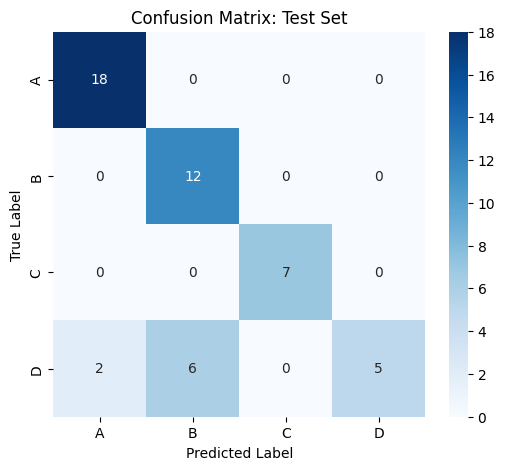

In [ ]:
# DO NOT MODIFY
# Run this code and observe the performance on the test set
# [pts depend on performance range]
model = learn_unnown_classifier(unnown_train_path)
evaluate_unnown_classifier(unnown_test_public_path, model)

<div style="color:red">
    
# ANSWER

</div>

## **EDIT: [1 pts]**
#### You can jot down the train and test metrics below

### **Test Set Performance**
  - Classification Accuracy: 0.84
  - Confusion Matrix: Shown Above

### **Any Additional Observations**
  -   I used a semi-supervised approach since less amount of labelled data available



<div style="color:red">

<hr>
<hr>
<hr>

# YOU CAN STOP THE TEST HERE -- BELOW EVALUATION TO BE PERFORMED BY INAIO

</div>

<div style="color:blue">

# **Q5: Testing your Unnown Classifier on New Private Dataset** [1 pt]

- Same metrics as Public Dataset

</div>